# Linear Regression

E: hata fonksiyonu, cost function

$y_i'$: tahmin edilen değer 

$y_i$: gerçek değer

$$E = \frac{1}{n} \sum_{i=0}^{n} (y_i - y_i')^2 $$
  

Hatayı optimize etmek için Gradient Descent metodu kullanılır. 

# Gradient Descent

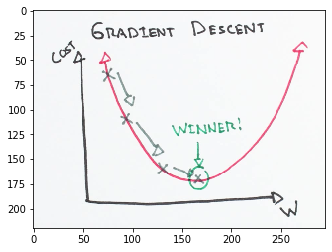

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image = mpimg.imread("images/gd.png")
plt.imshow(image)
plt.show()

$$ h(w,w_0) = y_i' $$  
$$ y_i' =  w_1 x + w_0 $$ 
$$ E(w,w_0) = \frac{1}{n} \sum_{i=0}^{n} (y_i - y_i')^2 $$
$$ E(w,w_0) = \frac{1}{n} \sum_{i=0}^{n} (y_i - (wx + w_0))^2 $$
$$ \frac{\partial E(w,w_0)}{\partial w_0}
   = \frac{2}{N} \sum_{i=0}^{n} -(y_i - (wx + w_0)) $$
      
$$ \frac{\partial E(w,w_0)}{\partial w}
   = \frac{2}{N} \sum_{i=0}^{n} -x(y_i - (wx + w_0)) $$  

Update Rule:

$\alpha$: learning rate

$$ w_{new} = w_{old} - \alpha \frac{\partial E(w,w_0)}{\partial w} $$

$$ w_{0new} = w_{0old} - \alpha \frac{\partial E(w,w_0)}{\partial w_0} $$

# Application

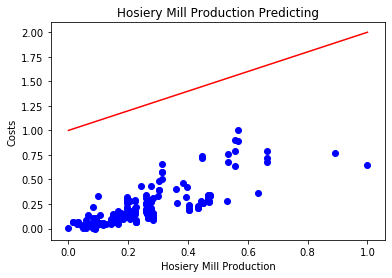

w: 1
b: 1
Error: 1.0771393737054835
w: 0.7895018763503294
b: 0.03414942860647437
Error: 0.014747912307722589


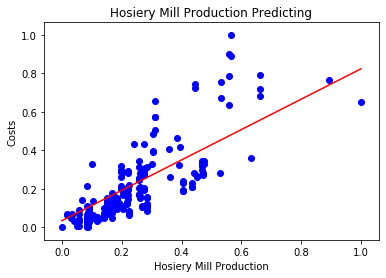

In [149]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import sys
from sklearn.datasets import load_boston


def loadData():
    dataset = pd.read_csv('dataset/CarPrice_Assignment.csv')
    #print(dataset.shape)
    #print(dataset.keys())
    x = dataset['horsepower']
    y = dataset['price']
    
    x = np.array(x, dtype=np.float64)
    y = np.array(y, dtype=np.float64)
    x_nor = (x - min(x)) / (max(x) - min(x))
    y_nor = (y - min(y)) / (max(y) - min(y))
    return x_nor,y_nor
    
def plotScatter(x,y):
    plt.scatter(x,y, c='b')
    plt.title('Car Price Predicting')
    plt.xlabel('horsepower')
    plt.ylabel('price')

def plotModel(w, b):
    # init. weights
    x = np.linspace(0,1)
    y = w*x + b
    plt.plot(x,y,'-r')
    plt.show()

def MSE_cal(w, b, x, y):
    size = len(x)
    summ = 0
    
    for i in range(size):
        sub = y[i] - (w*x[i] + b)
        sq = sub ** 2
        summ += sq
    
    error = summ/float(size)
    return error

def update_weights(w, b, x, y, learning_rate, iter_val):

    for j in range(iter_val):
        w_der = 0
        b_der = 0
        N = len(x)
        for i in range(N):
            # Calculate partial derivatives
            # -2x(y - (wx + b))
            w_der += (-2/N)*x[i] * (y[i] - (w*x[i] + b))
            # -2(y - (wx + b))
            b_der += (-2/N)*(y[i] - (w*x[i] + b))

        # We subtract because the derivatives point in direction of steepest ascent
        w = w - w_der * learning_rate
        b = b - b_der * learning_rate

    return w, b

if __name__ == "__main__":
    x,y = loadData()
    
    w = 1
    b = 1
    plotScatter(x,y)
    plotModel(w,b)
    
    # calculate error
    err = MSE_cal(w, b, x, y)    
    learning_rate = 0.0001
    print("w:",w)
    print("b:",b)
    print("Error:",err)
    
    w, b = update_weights(w, b, x, y, learning_rate,iter_val=20000)
    
    # calculate error
    err = MSE_cal(w, b, x, y)    
    print("w:",w)
    print("b:",b)
    print("Error:",err)
    plotScatter(x,y)
    plotModel(w,b)